# Starter

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 15.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=e57a3156d8e18fadfe1b8df0df18d4caae78d309eadc41b6037b5fd5240d424f
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

import shap
from lime import lime_tabular

from sklearn.inspection import permutation_importance

import os
import pickle

import warnings
warnings.filterwarnings("ignore")

print("Libraries Loaded")

Libraries Loaded


In [10]:
PROJECT_ROOT = "/content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense"

print("Project Root Set")

Project Root Set


In [11]:
def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

In [12]:
def save_and_show_plot(name):

    path = os.path.join(PROJECT_ROOT,"figures",name)

    plt.savefig(path, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close()

    print("Saved:", path)

In [13]:
# Load Feature Data

X_train_phish = np.load(os.path.join(PROJECT_ROOT,"data/X_train_phish.npy"))
X_test_phish = np.load(os.path.join(PROJECT_ROOT,"data/X_test_phish.npy"))

X_train_ids = np.load(os.path.join(PROJECT_ROOT,"data/X_train_ids.npy"))
X_test_ids = np.load(os.path.join(PROJECT_ROOT,"data/X_test_ids.npy"))

X_train_fraud = np.load(os.path.join(PROJECT_ROOT,"data/X_train_fraud.npy"))
X_test_fraud = np.load(os.path.join(PROJECT_ROOT,"data/X_test_fraud.npy"))

print("Datasets Loaded")

Datasets Loaded


In [14]:
feature_phish = load_pickle(
    os.path.join(PROJECT_ROOT,"data/feature_phish.pkl")
)

feature_ids = load_pickle(
    os.path.join(PROJECT_ROOT,"data/feature_ids.pkl")
)

feature_fraud = load_pickle(
    os.path.join(PROJECT_ROOT,"data/feature_fraud.pkl")
)

print("Feature names loaded")

Feature names loaded


In [15]:
# Logistic Models

log_phish = load_pickle(
    os.path.join(PROJECT_ROOT,"models/base_models/logistic_phish.pkl")
)

log_ids = load_pickle(
    os.path.join(PROJECT_ROOT,"models/base_models/logistic_ids.pkl")
)

log_fraud = load_pickle(
    os.path.join(PROJECT_ROOT,"models/base_models/logistic_fraud.pkl")
)

print("Logistic models loaded")

Logistic models loaded


In [16]:
# XGBoost Models

xgb_phish = load_pickle(
    os.path.join(PROJECT_ROOT,"models/base_models/xgb_phish.pkl")
)

xgb_ids = load_pickle(
    os.path.join(PROJECT_ROOT,"models/base_models/xgb_ids.pkl")
)

xgb_fraud = load_pickle(
    os.path.join(PROJECT_ROOT,"models/base_models/xgb_fraud.pkl")
)

print("XGBoost models loaded")

XGBoost models loaded


In [17]:
sns.set_style("whitegrid")
sns.set_context("talk")

print("SHAP Setup Ready")

SHAP Setup Ready


# SHAP for Phishing

In [44]:
explainer_phish = shap.TreeExplainer(xgb_phish)

shap_values_phish = explainer_phish.shap_values(
    X_test_phish[:500]
)

print("SHAP Values Generated")

SHAP Values Generated


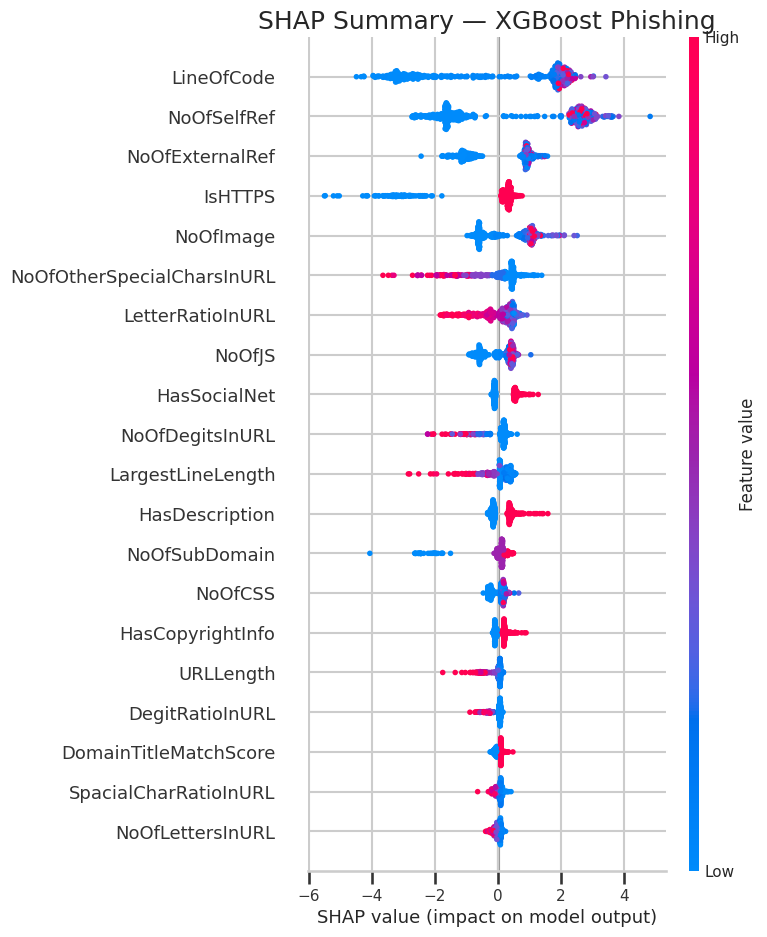

Saved: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/figures/SHAP_XGB_Phishing_Summary.png


In [45]:
plt.figure()

shap.summary_plot(
    shap_values_phish,
    X_test_phish[:500],
    feature_names=feature_phish,
    show=False
)

plt.title("SHAP Summary — XGBoost Phishing")

save_and_show_plot("SHAP_XGB_Phishing_Summary.png")

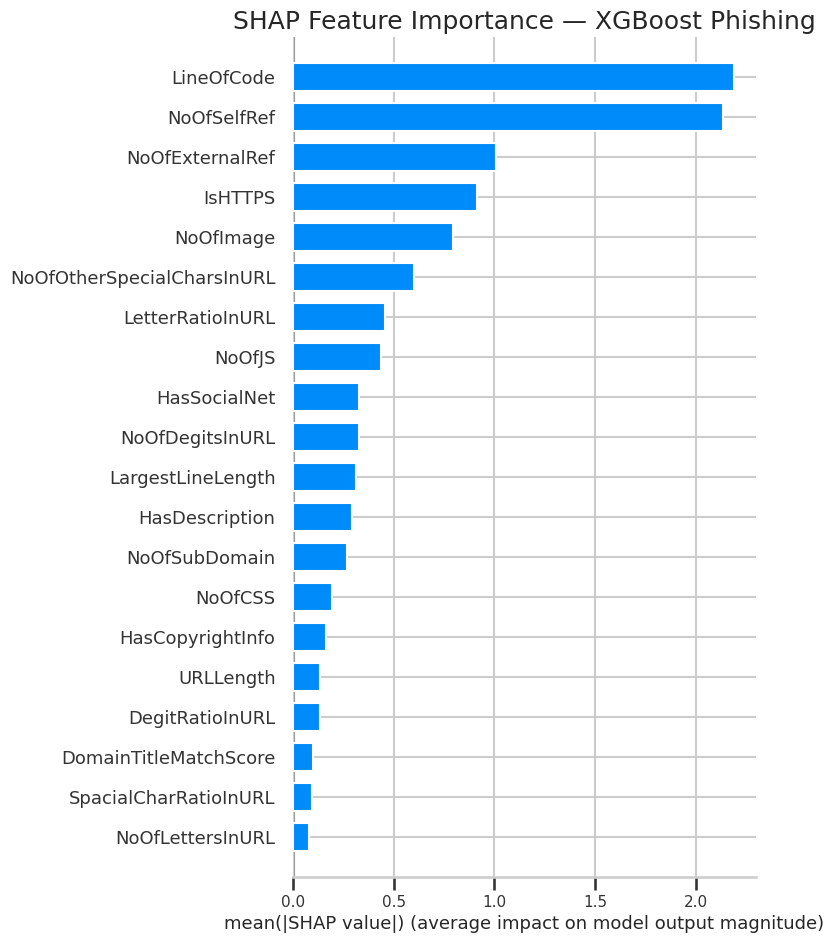

Saved: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/figures/SHAP_XGB_Phishing_Bar.png


In [46]:
plt.figure()

shap.summary_plot(
    shap_values_phish,
    X_test_phish[:500],
    feature_names=feature_phish,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance — XGBoost Phishing")

save_and_show_plot("SHAP_XGB_Phishing_Bar.png")

In [47]:
shap_mean = np.abs(shap_values_phish).mean(axis=0)

shap_table = pd.DataFrame({
    "Feature": feature_phish,
    "Importance": shap_mean
})

shap_table = shap_table.sort_values(
    by="Importance",
    ascending=False
)

shap_table.head(15)

,Feature,Importance
22,LineOfCode,2.189244
47,NoOfSelfRef,2.134536
49,NoOfExternalRef,1.008040
21,IsHTTPS,0.915176
44,NoOfImage,0.796400
19,NoOfOtherSpecialCharsInURL,0.603477
13,LetterRatioInURL,0.455960
46,NoOfJS,0.435433
36,HasSocialNet,0.329304
14,NoOfDegitsInURL,0.329163


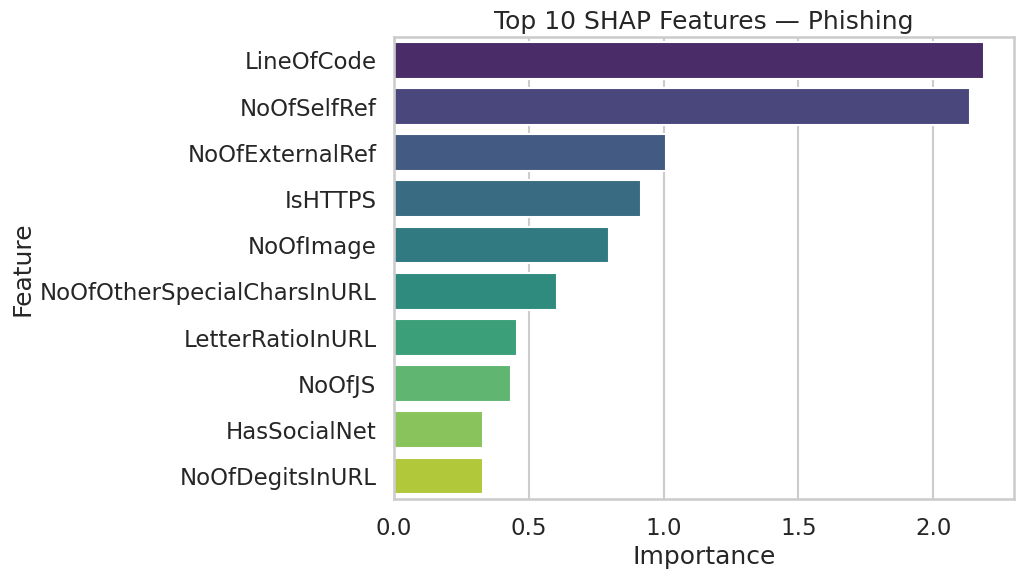

Saved: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/figures/Top_SHAP_Features_Phishing.png


In [48]:
top_features = shap_table.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 SHAP Features — Phishing")

save_and_show_plot("Top_SHAP_Features_Phishing.png")

# SHAP for IDS

In [50]:
explainer_ids = shap.TreeExplainer(xgb_ids)

shap_values_ids = explainer_ids.shap_values(
    X_test_ids[:500]
)

print("IDS SHAP values generated")

IDS SHAP values generated


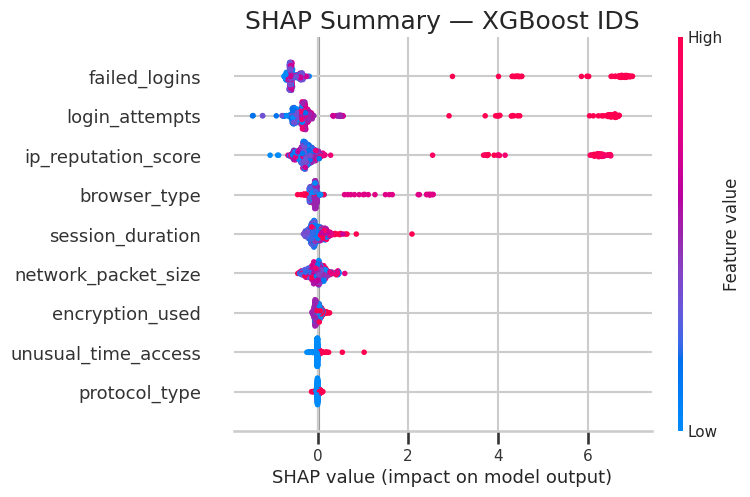

Saved: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/figures/SHAP_XGB_IDS_Summary.png


In [51]:
plt.figure()

shap.summary_plot(
    shap_values_ids,
    X_test_ids[:500],
    feature_names=feature_ids,
    show=False
)

plt.title("SHAP Summary — XGBoost IDS")

save_and_show_plot("SHAP_XGB_IDS_Summary.png")

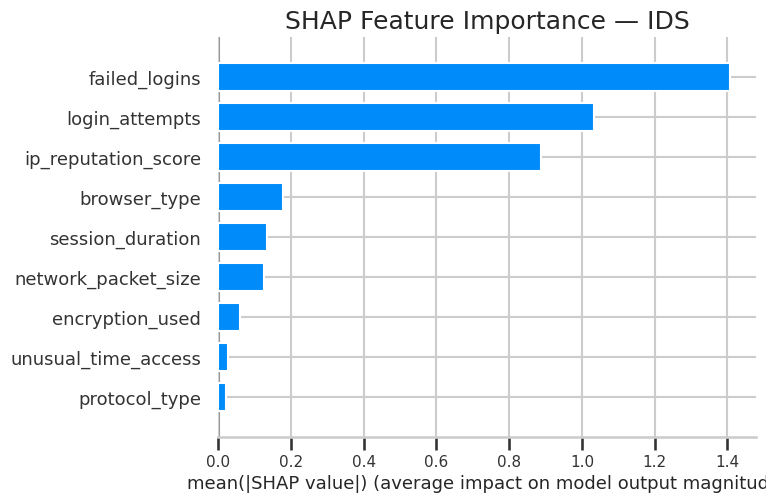

Saved: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/figures/SHAP_XGB_IDS_Bar.png


In [52]:
plt.figure()

shap.summary_plot(
    shap_values_ids,
    X_test_ids[:500],
    feature_names=feature_ids,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance — IDS")

save_and_show_plot("SHAP_XGB_IDS_Bar.png")

In [53]:
shap_mean_ids = np.abs(shap_values_ids).mean(axis=0)

shap_table_ids = pd.DataFrame({
    "Feature": feature_ids,
    "Importance": shap_mean_ids
})

shap_table_ids = shap_table_ids.sort_values(
    by="Importance",
    ascending=False
)

shap_table_ids.head(15)

,Feature,Importance
6,failed_logins,1.407988
2,login_attempts,1.033017
5,ip_reputation_score,0.887577
7,browser_type,0.178645
3,session_duration,0.132816
0,network_packet_size,0.126349
4,encryption_used,0.060177
8,unusual_time_access,0.027385
1,protocol_type,0.020562


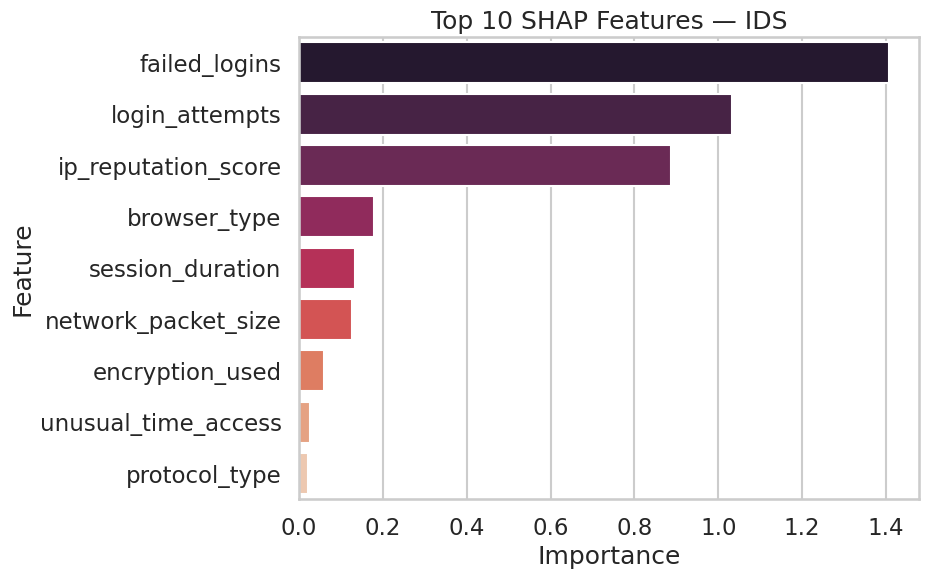

Saved: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/figures/Top_SHAP_Features_IDS.png


In [54]:
top_features_ids = shap_table_ids.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_features_ids,
    x="Importance",
    y="Feature",
    palette="rocket"
)

plt.title("Top 10 SHAP Features — IDS")

save_and_show_plot("Top_SHAP_Features_IDS.png")

# SHAP for Fraud

In [55]:
explainer_fraud = shap.TreeExplainer(xgb_fraud)

shap_values_fraud = explainer_fraud.shap_values(
    X_test_fraud
)

print("Fraud SHAP values generated")

Fraud SHAP values generated


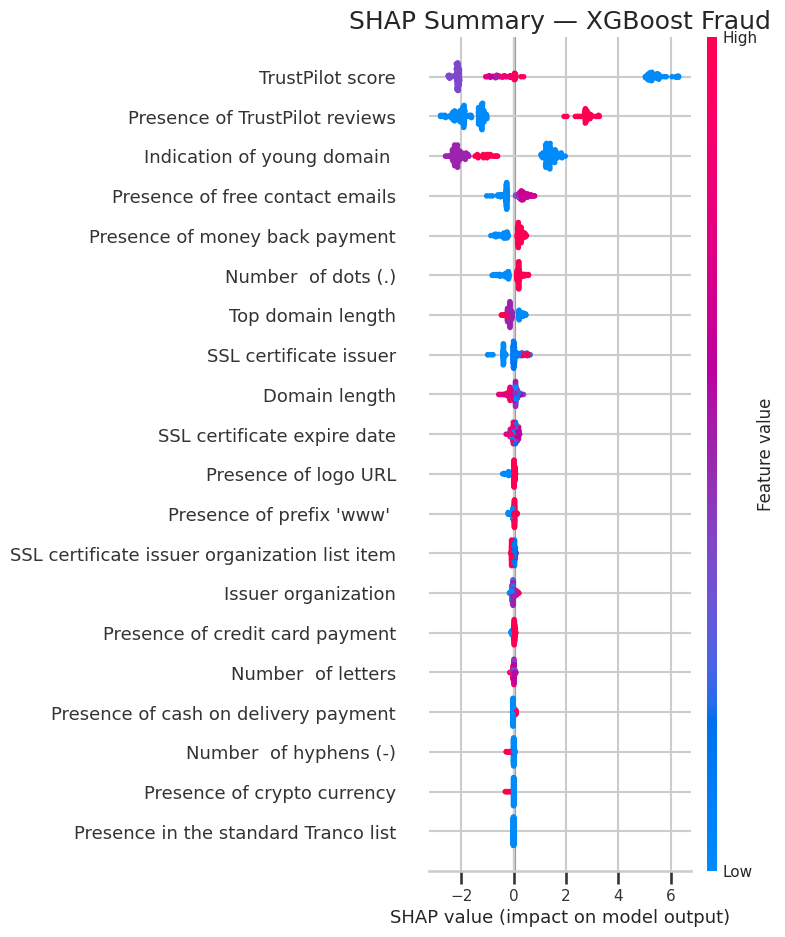

Saved: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/figures/SHAP_XGB_Fraud_Summary.png


In [56]:
plt.figure()

shap.summary_plot(
    shap_values_fraud,
    X_test_fraud,
    feature_names=feature_fraud,
    show=False
)

plt.title("SHAP Summary — XGBoost Fraud")

save_and_show_plot("SHAP_XGB_Fraud_Summary.png")

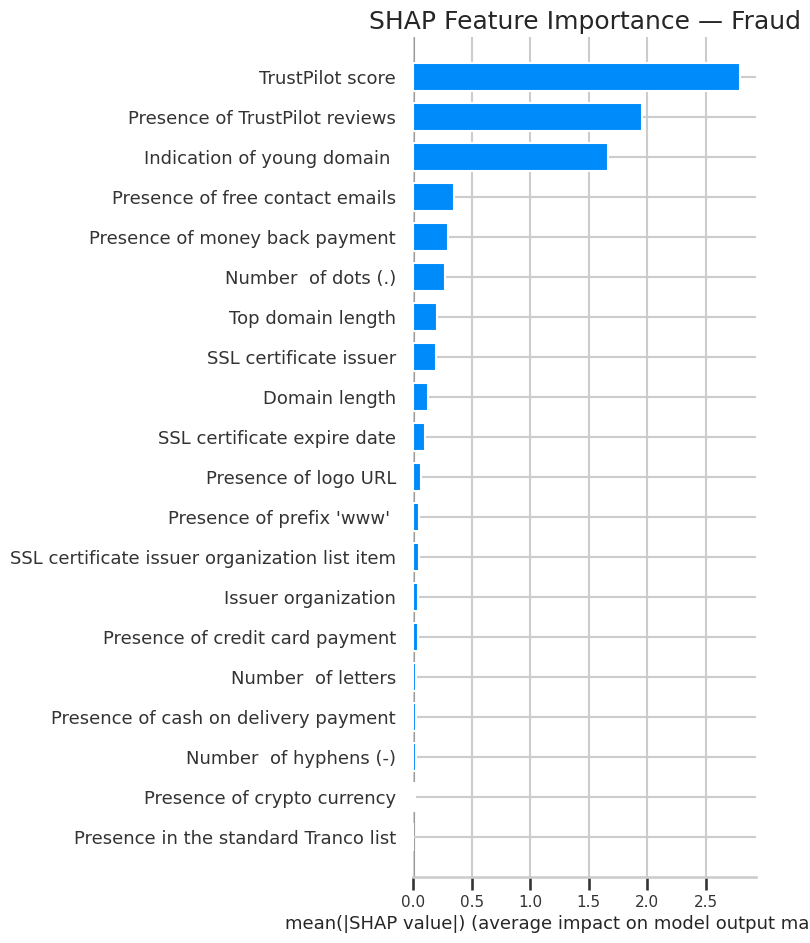

Saved: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/figures/SHAP_XGB_Fraud_Bar.png


In [57]:
plt.figure()

shap.summary_plot(
    shap_values_fraud,
    X_test_fraud,
    feature_names=feature_fraud,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance — Fraud")

save_and_show_plot("SHAP_XGB_Fraud_Bar.png")

In [58]:
shap_mean_fraud = np.abs(shap_values_fraud).mean(axis=0)

shap_table_fraud = pd.DataFrame({
    "Feature": feature_fraud,
    "Importance": shap_mean_fraud
})

shap_table_fraud = shap_table_fraud.sort_values(
    by="Importance",
    ascending=False
)

shap_table_fraud.head(15)

,Feature,Importance
19,TrustPilot score,2.791974
18,Presence of TrustPilot reviews,1.957927
17,Indication of young domain,1.664013
11,Presence of free contact emails,0.348342
8,Presence of money back payment,0.295184
5,Number of dots (.),0.266947
1,Top domain length,0.198872
13,SSL certificate issuer,0.194895
0,Domain length,0.124573
14,SSL certificate expire date,0.097638


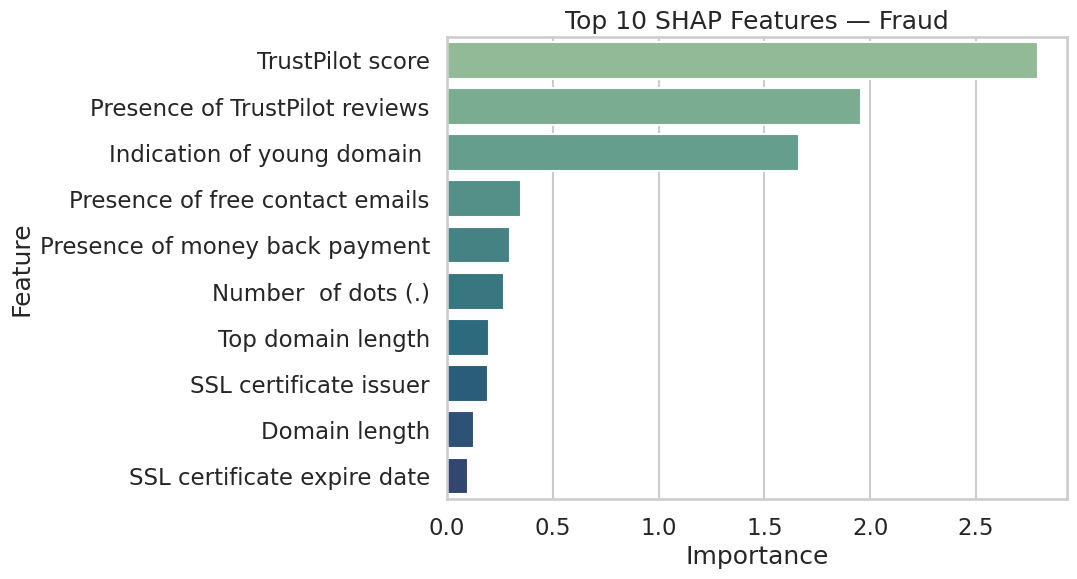

Saved: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/figures/Top_SHAP_Features_Fraud.png


In [59]:
top_features_fraud = shap_table_fraud.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_features_fraud,
    x="Importance",
    y="Feature",
    palette="crest"
)

plt.title("Top 10 SHAP Features — Fraud")

save_and_show_plot("Top_SHAP_Features_Fraud.png")

# LIME

In [71]:
from lime.lime_tabular import LimeTabularExplainer

print("LIME Imported Successfully")

LIME Imported Successfully


In [72]:
# Phishing Explainer
lime_phish = LimeTabularExplainer(
    training_data=X_train_phish,
    feature_names=feature_phish,
    class_names=["Legitimate","Phishing"],
    mode="classification"
)

# IDS Explainer
lime_ids = LimeTabularExplainer(
    training_data=X_train_ids,
    feature_names=feature_ids,
    class_names=["Normal","Attack"],
    mode="classification"
)

# Fraud Explainer
lime_fraud = LimeTabularExplainer(
    training_data=X_train_fraud,
    feature_names=feature_fraud,
    class_names=["Legitimate","Fraud"],
    mode="classification"
)

print("All LIME Explainers Created")

All LIME Explainers Created


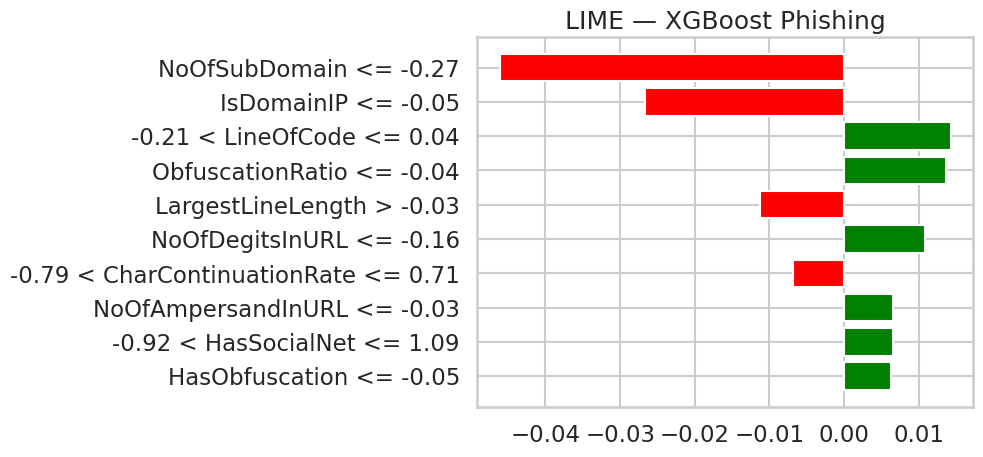

LIME Phishing saved


In [77]:
# Generate Explanation
exp = lime_phish.explain_instance(
    X_test_phish[0],
    xgb_phish.predict_proba,
    num_features=10
)

# Plot
fig = exp.as_pyplot_figure()
plt.title("LIME — XGBoost Phishing")
plt.show()
# Save
plt.savefig(
    os.path.join(PROJECT_ROOT,"figures","LIME_XGB_Phishing.png"),
    bbox_inches="tight",
    dpi=300
)
plt.close()
print("LIME Phishing saved")

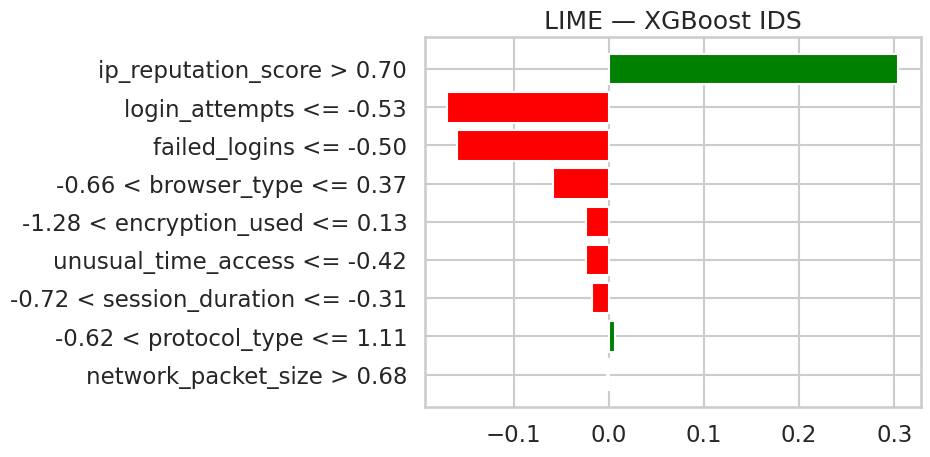

LIME IDS saved


In [78]:
exp_ids = lime_ids.explain_instance(
    X_test_ids[0],
    xgb_ids.predict_proba,
    num_features=10
)

fig = exp_ids.as_pyplot_figure()

plt.title("LIME — XGBoost IDS")

plt.show()

plt.savefig(
    os.path.join(PROJECT_ROOT,"figures","LIME_XGB_IDS.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()

print("LIME IDS saved")

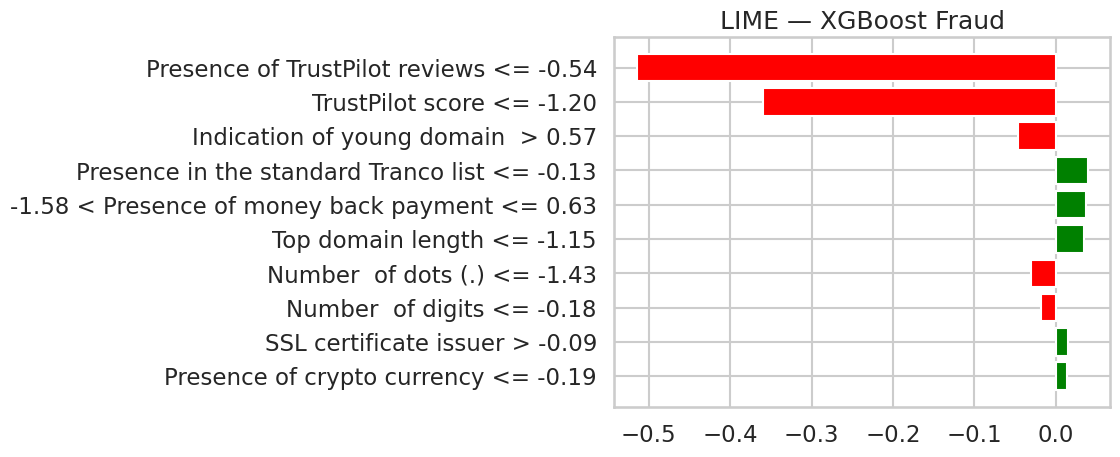

LIME Fraud saved


In [79]:
exp_fraud = lime_fraud.explain_instance(
    X_test_fraud[0],
    xgb_fraud.predict_proba,
    num_features=10
)

fig = exp_fraud.as_pyplot_figure()

plt.title("LIME — XGBoost Fraud")

plt.show()

plt.savefig(
    os.path.join(PROJECT_ROOT,"figures","LIME_XGB_Fraud.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()

print("LIME Fraud saved")

# Permutation Importance

In [80]:
from sklearn.inspection import permutation_importance

perm_phish = permutation_importance(
    xgb_phish,
    X_test_phish,
    y_test_phish,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_table_phish = pd.DataFrame({
    "Feature": feature_phish,
    "Importance": perm_phish.importances_mean
})

perm_table_phish = perm_table_phish.sort_values(
    by="Importance",
    ascending=False
)

perm_table_phish.head(15)

,Feature,Importance
21,IsHTTPS,0.125289
8,NoOfSubDomain,0.033328
22,LineOfCode,0.014006
47,NoOfSelfRef,0.008832
19,NoOfOtherSpecialCharsInURL,0.000744
23,LargestLineLength,0.000295
13,LetterRatioInURL,0.000246
14,NoOfDegitsInURL,0.000151
44,NoOfImage,0.000146
49,NoOfExternalRef,0.000040


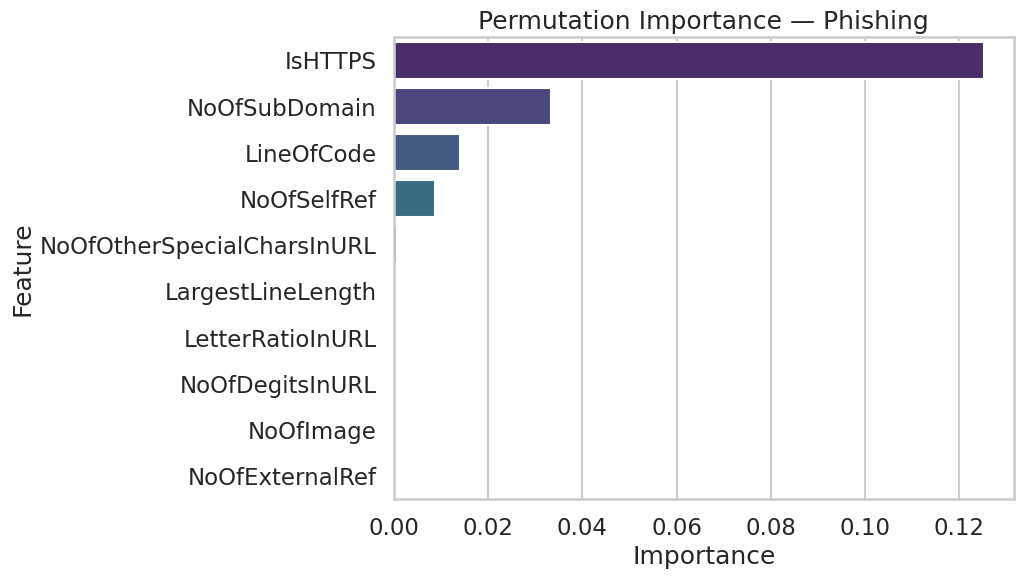

In [81]:
top_perm_phish = perm_table_phish.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_perm_phish,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Permutation Importance — Phishing")

plt.show()

plt.savefig(
    os.path.join(PROJECT_ROOT,"figures","Permutation_Phishing.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()

In [82]:
perm_ids = permutation_importance(
    xgb_ids,
    X_test_ids,
    y_test_ids,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_table_ids = pd.DataFrame({
    "Feature": feature_ids,
    "Importance": perm_ids.importances_mean
})

perm_table_ids = perm_table_ids.sort_values(
    by="Importance",
    ascending=False
)

perm_table_ids.head(15)

,Feature,Importance
6,failed_logins,0.179874
2,login_attempts,0.127306
5,ip_reputation_score,0.095755
7,browser_type,0.029140
3,session_duration,0.004822
8,unusual_time_access,0.003669
0,network_packet_size,0.000157
4,encryption_used,0.000000
1,protocol_type,0.000000


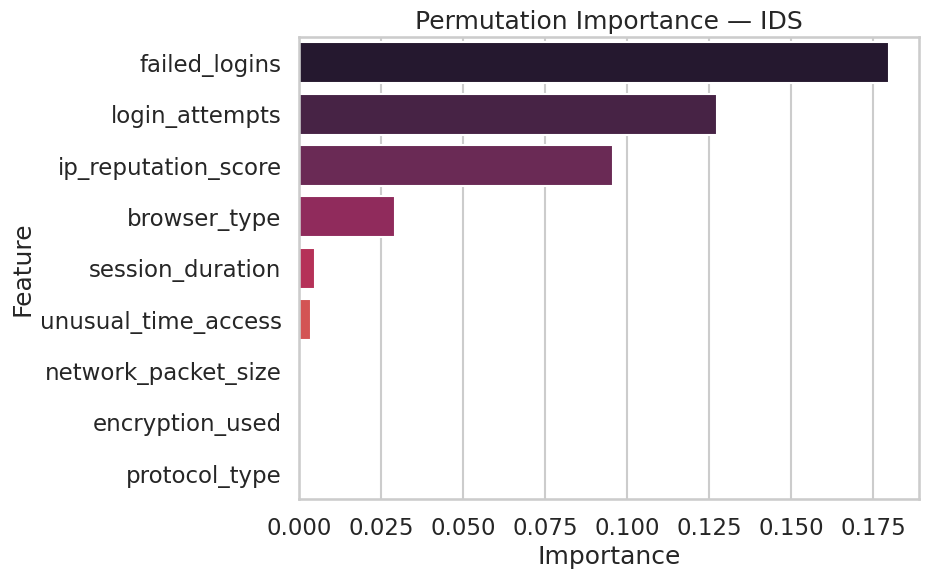

In [83]:
top_perm_ids = perm_table_ids.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_perm_ids,
    x="Importance",
    y="Feature",
    palette="rocket"
)

plt.title("Permutation Importance — IDS")

plt.show()

plt.savefig(
    os.path.join(PROJECT_ROOT,"figures","Permutation_IDS.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()

In [85]:
from sklearn.preprocessing import LabelEncoder

# Encode Fraud Labels
le_fraud = LabelEncoder()
y_test_fraud_encoded = le_fraud.fit_transform(y_test_fraud)

# Permutation Importance
perm_fraud = permutation_importance(
    xgb_fraud,
    X_test_fraud,
    y_test_fraud_encoded,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_table_fraud = pd.DataFrame({
    "Feature": feature_fraud,
    "Importance": perm_fraud.importances_mean
})

perm_table_fraud = perm_table_fraud.sort_values(
    by="Importance",
    ascending=False
)

perm_table_fraud.head(15)

,Feature,Importance
19,TrustPilot score,0.366228
18,Presence of TrustPilot reviews,0.144298
17,Indication of young domain,0.005702
2,Presence of prefix 'www',0.005263
6,Number of hyphens (-),0.003070
1,Top domain length,0.002193
11,Presence of free contact emails,0.001754
5,Number of dots (.),0.001754
9,Presence of cash on delivery payment,0.000877
13,SSL certificate issuer,0.000439


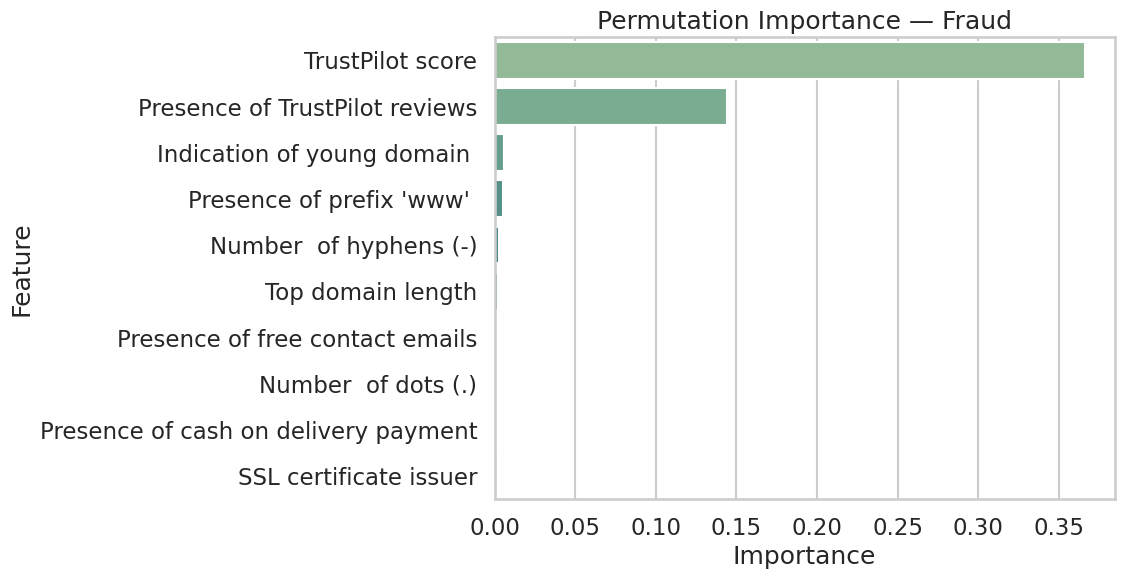

In [86]:
top_perm_fraud = perm_table_fraud.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_perm_fraud,
    x="Importance",
    y="Feature",
    palette="crest"
)

plt.title("Permutation Importance — Fraud")

plt.show()

plt.savefig(
    os.path.join(PROJECT_ROOT,"figures","Permutation_Fraud.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()

# IG

In [1]:
!pip install captum

In [2]:
from captum.attr import IntegratedGradients
import torch

print("Captum Loaded")

Captum Loaded


In [4]:
# Define same MLP architecture (must match File 02)
import torch
import torch.nn as nn

class MLP(nn.Module):

    def __init__(self, input_dim):
        super(MLP, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [18]:
# Phishing
nn_phish = MLP(X_train_phish.shape[1])
nn_phish.load_state_dict(
    torch.load(
        os.path.join(PROJECT_ROOT,"models/base_models/nn_phish.pt")
    )
)
nn_phish.eval()

# IDS
nn_ids = MLP(X_train_ids.shape[1])
nn_ids.load_state_dict(
    torch.load(
        os.path.join(PROJECT_ROOT,"models/base_models/nn_ids_improved.pt")
    )
)
nn_ids.eval()

# Fraud
nn_fraud = MLP(X_train_fraud.shape[1])
nn_fraud.load_state_dict(
    torch.load(
        os.path.join(PROJECT_ROOT,"models/base_models/nn_fraud.pt")
    )
)
nn_fraud.eval()

print("Neural Models Loaded")

Neural Models Loaded


## IG for Phishing

In [19]:
ig = IntegratedGradients(nn_phish)

input_tensor = torch.tensor(
    X_test_phish[0:1],
    dtype=torch.float32
)

attr, delta = ig.attribute(
    input_tensor,
    return_convergence_delta=True
)

attr = attr.detach().numpy()[0]

ig_table_phish = pd.DataFrame({
    "Feature": feature_phish,
    "Importance": np.abs(attr)
})

ig_table_phish = ig_table_phish.sort_values(
    by="Importance",
    ascending=False
)

ig_table_phish.head(15)

,Feature,Importance
32,HasDescription,0.046785
43,HasCopyrightInfo,0.042512
36,HasSocialNet,0.037859
21,IsHTTPS,0.031881
29,IsResponsive,0.027921
26,URLTitleMatchScore,0.027797
38,HasHiddenFields,0.027144
25,DomainTitleMatchScore,0.026541
20,SpacialCharRatioInURL,0.024288
6,URLCharProb,0.022582


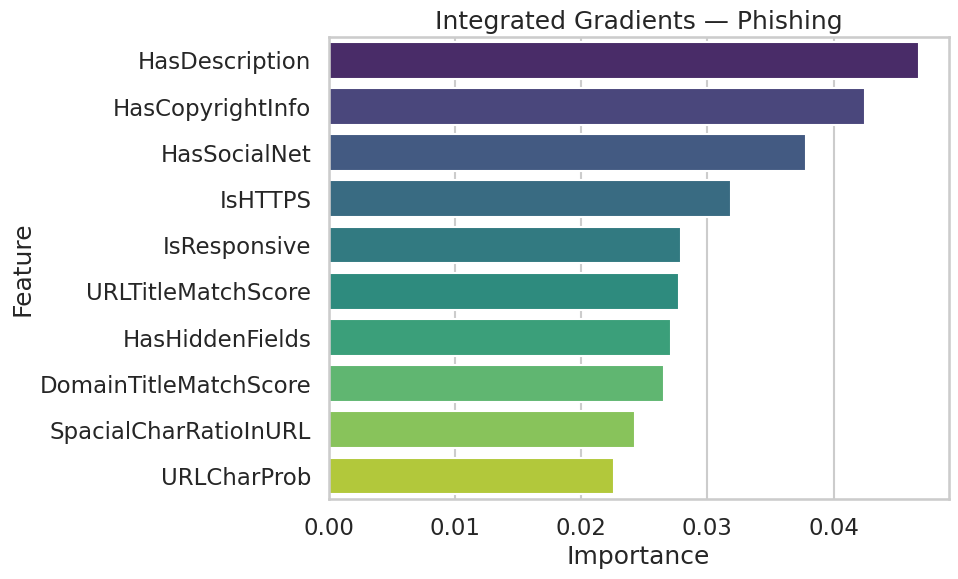

In [20]:
top_ig_phish = ig_table_phish.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_ig_phish,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Integrated Gradients — Phishing")

plt.show()

plt.savefig(
    os.path.join(PROJECT_ROOT,"figures","IG_Phishing.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()

## IG for IDS

In [21]:
ig_ids = IntegratedGradients(nn_ids)

input_tensor_ids = torch.tensor(
    X_test_ids[0:1],
    dtype=torch.float32
)

attr_ids, delta = ig_ids.attribute(
    input_tensor_ids,
    return_convergence_delta=True
)

attr_ids = attr_ids.detach().numpy()[0]

ig_table_ids = pd.DataFrame({
    "Feature": feature_ids,
    "Importance": np.abs(attr_ids)
})

ig_table_ids = ig_table_ids.sort_values(
    by="Importance",
    ascending=False
)

ig_table_ids.head(15)

,Feature,Importance
5,ip_reputation_score,0.951657
6,failed_logins,0.120927
1,protocol_type,0.077281
2,login_attempts,0.055903
7,browser_type,0.030882
0,network_packet_size,0.022822
3,session_duration,0.008179
4,encryption_used,0.004501
8,unusual_time_access,0.001571


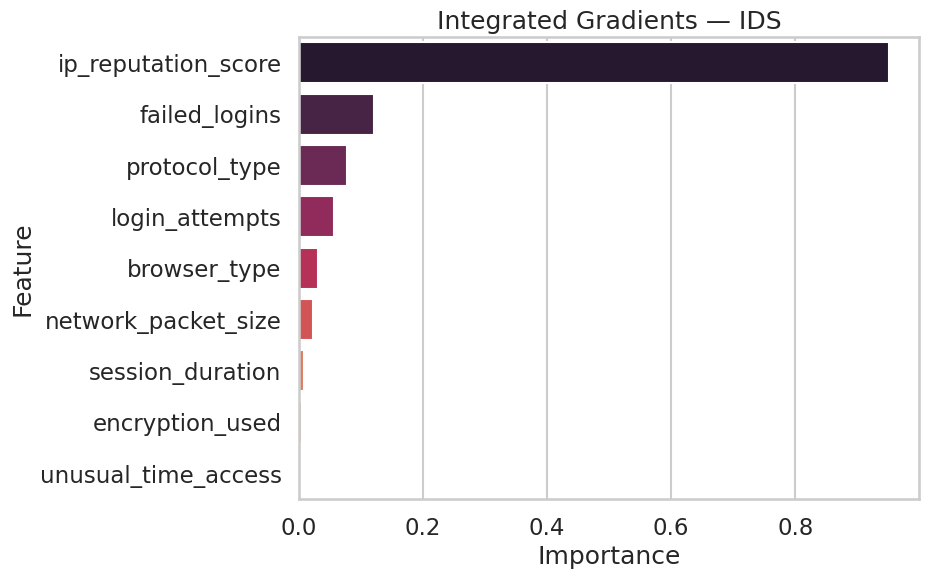

In [22]:
top_ig_ids = ig_table_ids.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_ig_ids,
    x="Importance",
    y="Feature",
    palette="rocket"
)

plt.title("Integrated Gradients — IDS")

plt.show()

plt.savefig(
    os.path.join(PROJECT_ROOT,"figures","IG_IDS.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()

## IG for Fraud

In [23]:
ig_fraud = IntegratedGradients(nn_fraud)

input_tensor_fraud = torch.tensor(
    X_test_fraud[0:1],
    dtype=torch.float32
)

attr_fraud, delta = ig_fraud.attribute(
    input_tensor_fraud,
    return_convergence_delta=True
)

attr_fraud = attr_fraud.detach().numpy()[0]

ig_table_fraud = pd.DataFrame({
    "Feature": feature_fraud,
    "Importance": np.abs(attr_fraud)
})

ig_table_fraud = ig_table_fraud.sort_values(
    by="Importance",
    ascending=False
)

ig_table_fraud.head(15)

,Feature,Importance
17,Indication of young domain,0.308908
13,SSL certificate issuer,0.299064
0,Domain length,0.178050
19,TrustPilot score,0.153795
1,Top domain length,0.123903
2,Presence of prefix 'www',0.082786
15,Issuer organization,0.068054
8,Presence of money back payment,0.056650
4,Number of letters,0.053268
18,Presence of TrustPilot reviews,0.051354


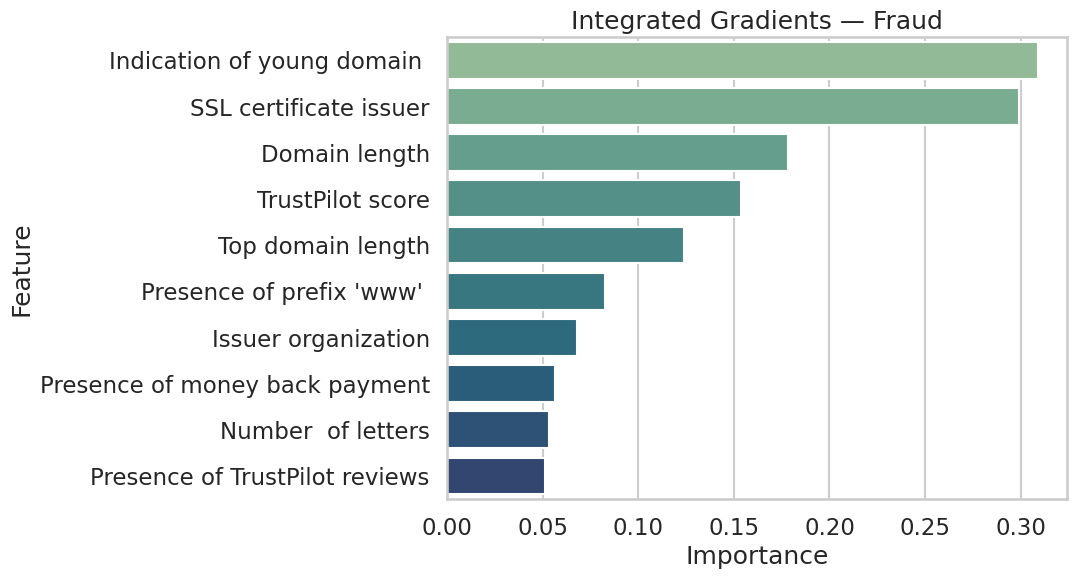

In [24]:
top_ig_fraud = ig_table_fraud.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_ig_fraud,
    x="Importance",
    y="Feature",
    palette="crest"
)

plt.title("Integrated Gradients — Fraud")

plt.show()

plt.savefig(
    os.path.join(PROJECT_ROOT,"figures","IG_Fraud.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()